import IBM AMLSim

In [ ]:
from loader.dataset_factory import DatasetFactory

# Inizializza il loader specificando il nome canonico del dataset
loader = DatasetFactory.get_loader("ibm_amlsim")

# Carica i dati in memoria (file delle transazioni e, se presente, degli account)
loader.load()

# Stampa un riepilogo conciso del dataset caricato per verificare che sia tutto ok
loader.summary()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading IBM AMLSim transactions from: c:\Users\marti\Desktop\Magistrale\Tesi v2\Code\loader\..\data\ibm_amlsim\HI-Small_Trans.csv
  Loaded 5,078,345 rows.
Loading IBM AMLSim accounts from: c:\Users\marti\Desktop\Magistrale\Tesi v2\Code\loader\..\data\ibm_amlsim\HI-Small_accounts.csv
  Loaded 518,581 account records.
  Dataset : IBMAMLSimLoader
  Rows    : 5,078,345
  Columns : 11
  Fraud   : 5,177  (0.1019 %)



In [3]:
loader.print_features()



Column               Type         Description
--------------------------------------------------------------------------------
Timestamp            object       Date and time of the transaction
From Bank            int64        Numeric identifier of the originating bank  (e.g. [1, 10, 12, 3208, 3209])
Account              object       Hexadecimal ID of the sender account (node)
To Bank              int64        Numeric identifier of the receiving bank  (e.g. [1, 10, 12, 2439, 3209])
Account.1            object       Hexadecimal ID of the receiver account (node)
Amount Received      float64      Transaction amount in the receiving currency
Receiving Currency   object       Currency received by the destination account  (e.g. ['US Dollar', 'Bitcoin', 'Euro', 'Australian Dollar', 'Yuan', 'Rupee'])
Amount Paid          float64      Transaction amount in the paying currency
Payment Currency     object       Currency used by the sender  (e.g. ['US Dollar', 'Bitcoin', 'Euro', 'Australian Doll

Data preparation

In [4]:
from data_preparation import DataPreparation

# Otteniamo il dataframe raw delle transazioni dal nostro loader
transactions_df = loader.get_transactions()

# Inizializziamo la classe scegliendo il robust scaler
data_prep = DataPreparation(scaler_type='robust')

# 1. Calcoliamo le feature standardizzate per le transazioni (gli archi E)
edges_features_df = data_prep.fit_transform_edges(transactions_df)

# 2. Aggreghiamo le transazioni per ricavare l'embedding iniziale dei nodi (V)
nodes_features_df = data_prep.get_node_features(edges_features_df)

print(f"Dimensione feature archi: {edges_features_df.shape}")
print(f"Dimensione feature nodi: {nodes_features_df.shape}")


Extracting time features (Unix time, Cyclic Hour, Day of Week)...
Applying edge transformation (Amounts: robust, Time: standard)...
Aggregating node features and extracting ground truth labels...
Dimensione feature archi: (5078345, 52)
Dimensione feature nodi: (515080, 49)



### GAGNN Model Setup & Hyperparameters

Below are the key hyperparameters for the GAGNN implementation. All values are defined in the code cell below.

**Model Architecture:**
- `node_in_dim`: Dimension of input node features (inferred from data).
- `edge_feat_dim`: Dimension of edge features (inferred from data).
- `hidden_dim`: Hidden dimension for GAT layers (from paper's GAT#1 units).
- `out_dim`: Output dimension of the community-centric encoder.
- `heads`: Number of attention heads $k$ (as per paper).
- `beta`: Trade-off parameter for eMRF similarity.

**Loss Optimization ($\mathcal{L} = \eta \mathcal{L}_{group} + \lambda \mathcal{L}_{node} + \zeta \mathcal{L}_{trans}$):**
- `eta`: Weight for the group-level loss term.
- `lambda_`: Weight for the node-level loss term.
- `zeta`: Weight for the transaction-level loss term.

**Training:**
- `learning_rate`: Learning rate for the Adam optimizer (from paper).
- `epochs`: Number of full passes over the training batches.

**Mini-batch Sampling (NeighborLoader):**
- `batch_size`: Number of seed nodes processed per mini-batch.
- `num_neighbors`: List of neighbors sampled per hop for each GAT layer. Length must match the number of GAT layers (2).


In [5]:
# =============================================================================
# Hyperparameters — edit these values to configure the model and training
# =============================================================================

# Model Architecture
hidden_dim    = 64       # Hidden dimension for GAT layers
out_dim       = 64       # Output dimension of community-centric encoder
heads         = 5        # Number of GAT attention heads
beta          = 0.44     # eMRF trade-off parameter

# Loss weights
eta           = 1.0      # Group loss weight
lambda_       = 1.0      # Node loss weight
zeta          = 1.0      # Transaction loss weight

# Training
learning_rate = 0.001    # Adam optimizer learning rate
epochs        = 100      # Maximum number of training epochs
patience      = 5        # Early stopping patience (epochs without val improvement)

# Class Imbalance
downsample    = True     # Down-sample majority class (legitimate nodes) in training set

# Mini-batch Sampling (NeighborLoader)
batch_size    = 512      # Seed nodes per batch
num_neighbors = [25, 25] # Neighbors sampled per hop (one entry per GAT layer)


In [6]:
import torch
import numpy as np

# 1. Map string Account IDs to integers (0 to N-1) for PyTorch Geometric
unique_nodes = nodes_features_df.index.unique()
node_mapping = {node_id: idx for idx, node_id in enumerate(unique_nodes)}

# 2. Extract edge_index
src = edges_features_df['Account'].map(node_mapping).values
dst = edges_features_df['Account.1'].map(node_mapping).values
edge_index = torch.tensor(np.vstack((src, dst)), dtype=torch.long)

# 3. Extract edge features and transaction labels
edge_features_cols = [c for c in edges_features_df.columns if c not in ['Account', 'Account.1', 'Is Laundering']]
edge_attr = torch.tensor(edges_features_df[edge_features_cols].values, dtype=torch.float)
y_trans = torch.tensor(edges_features_df['Is Laundering'].values, dtype=torch.float).unsqueeze(1)

# 4. Extract node features and node labels
node_features_cols = [c for c in nodes_features_df.columns if c != 'Is Laundering']
x = torch.tensor(nodes_features_df[node_features_cols].values, dtype=torch.float)

# If a node was involved in at least one ML transaction, label it as 1 (suspicious)
# Or just use the soft probability. The paper uses binary node labels.
y_node = torch.tensor((nodes_features_df['Is Laundering'] > 0).astype(float).values, dtype=torch.float)

print(f"Node features shape: {x.shape}")
print(f"Edge index shape: {edge_index.shape}")
print(f"Edge features shape: {edge_attr.shape}")


Node features shape: torch.Size([515080, 48])
Edge index shape: torch.Size([2, 5078345])
Edge features shape: torch.Size([5078345, 49])


In [7]:
from model.gagnn import GAGNN
from model.loss import GAGNNLoss

# Ensure device is set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Move tensors to device
x = x.to(device)
edge_index = edge_index.to(device)
edge_attr = edge_attr.to(device)
y_node = y_node.to(device)
y_trans = y_trans.to(device)
num_edges = edge_index.shape[1]

# Instantiate Model
model = GAGNN(
    node_in_dim=x.shape[1],
    edge_feat_dim=edge_attr.shape[1],
    hidden_dim=hidden_dim,
    out_dim=out_dim,
    heads=heads,
    beta=beta
).to(device)

# Instantiate Loss and Optimizer
criterion = GAGNNLoss(eta=eta, lambda_=lambda_, zeta=zeta)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(model)


c:\Users\marti\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GAGNN(
  (encoder): CommunityCentricEncoder(
    (gat1): GATConv(48, 64, heads=5)
    (gat2): GATConv(64, 64, heads=5)
    (emrf): eMRFLayer(
      (H2): Linear(in_features=64, out_features=64, bias=False)
    )
    (nn_t): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=1, bias=True)
    )
    (coarse_classifier): Linear(in_features=64, out_features=1, bias=True)
  )
  (group_layer): GroupRepresentationLayer(
    (mlp): Sequential(
      (0): Linear(in_features=177, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (group_encoder): CommunityCentricEncoder(
    (gat1): GATConv(64, 64, heads=5)
    (gat2): GATConv(64, 64, heads=5)
    (emrf): eMRFLayer(
      (H2): Linear(in_features=64, out_features=64, bias=False)
    )
    (nn_t): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
  

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader

# --- Train / Val / Test Split Masks (70 / 10 / 20) ---
all_idx = np.arange(x.shape[0])

# Step 1: hold out 30% as the temporary "rest" set
train_idx, rest_idx = train_test_split(all_idx, test_size=0.30, random_state=42)

# Step 2: split the 30% rest into val (10%) and test (20%)
val_idx, test_idx = train_test_split(rest_idx, test_size=2/3, random_state=42)

# --- Down-sampling (training set only) ---
if downsample:
    train_labels = y_node[train_idx].cpu().numpy()
    pos_idx = train_idx[train_labels == 1]
    neg_idx = train_idx[train_labels == 0]
    n_pos, n_neg = len(pos_idx), len(neg_idx)
    if n_neg > n_pos:
        neg_idx_sampled = np.random.choice(neg_idx, size=n_pos, replace=False)
        train_idx = np.concatenate([pos_idx, neg_idx_sampled])
        print(f"Down-sampling: {n_pos} pos + {n_pos} neg sampled (from {n_neg}) -> {len(train_idx)} train nodes")
    else:
        print(f"Down-sampling skipped: already balanced (pos={n_pos}, neg={n_neg})")

def make_mask(indices, n):
    mask = torch.zeros(n, dtype=torch.bool)
    mask[indices] = True
    return mask

n_nodes = x.shape[0]
train_node_mask = make_mask(train_idx, n_nodes)
val_node_mask   = make_mask(val_idx,   n_nodes)
test_node_mask  = make_mask(test_idx,  n_nodes)

print(f"Train nodes : {train_node_mask.sum().item()} ({train_node_mask.sum().item()/n_nodes*100:.1f}%)")
print(f"Val nodes   : {val_node_mask.sum().item()}   ({val_node_mask.sum().item()/n_nodes*100:.1f}%)")
print(f"Test nodes  : {test_node_mask.sum().item()}  ({test_node_mask.sum().item()/n_nodes*100:.1f}%)")
print("-" * 50)

# --- Package graph into a PyG Data object ---
# Tensors must be on CPU for NeighborLoader
data = Data(
    x=x.cpu(),
    edge_index=edge_index.cpu(),
    edge_attr=edge_attr.cpu(),
    y_node=y_node.cpu(),
    y_trans=y_trans.cpu()
)

# --- Build NeighborLoaders ---
train_loader = NeighborLoader(
    data, num_neighbors=num_neighbors, batch_size=batch_size,
    input_nodes=train_node_mask.cpu(), shuffle=True
)
val_loader = NeighborLoader(
    data, num_neighbors=num_neighbors, batch_size=batch_size,
    input_nodes=val_node_mask.cpu(), shuffle=False
)
test_loader = NeighborLoader(
    data, num_neighbors=num_neighbors, batch_size=batch_size,
    input_nodes=test_node_mask.cpu(), shuffle=False
)

# --- Early Stopping State ---
best_val_loss    = float('inf')
patience_counter = 0
model.val_losses = []          # track validation losses (mirrors model.training_losses)

# --- Mini-batch Training Loop with Early Stopping ---
for epoch in range(epochs):

    # ── Train ────────────────────────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        p_node, p_trans, p_group, y_group = model(
            batch.x, batch.edge_index, batch.edge_attr, batch.num_edges
        )

        if p_group.numel() > 0:
            n_seed = batch.batch_size
            seed_node_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
            seed_node_mask[:n_seed] = True
            all_edge_mask = torch.ones(batch.edge_index.shape[1], dtype=torch.bool, device=device)

            loss, l_node, l_trans, l_group = criterion(
                p_node, batch.y_node.view(-1, 1),
                p_trans, batch.y_trans,
                p_group, y_group,
                node_mask=seed_node_mask,
                trans_mask=all_edge_mask
            )

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            num_batches += 1

    avg_train_loss = epoch_loss / max(num_batches, 1)
    model.training_losses.append(avg_train_loss)

    # ── Validate ─────────────────────────────────────────────────────────────────────────────
    model.eval()
    val_loss_total = 0.0
    n_val_batches  = 0

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            p_node, p_trans, p_group, y_group = model(
                batch.x, batch.edge_index, batch.edge_attr, batch.num_edges
            )
            if p_group.numel() > 0:
                n_seed = batch.batch_size
                seed_node_mask = torch.zeros(batch.num_nodes, dtype=torch.bool, device=device)
                seed_node_mask[:n_seed] = True
                all_edge_mask = torch.ones(batch.edge_index.shape[1], dtype=torch.bool, device=device)

                val_loss, *_ = criterion(
                    p_node, batch.y_node.view(-1, 1),
                    p_trans, batch.y_trans,
                    p_group, y_group,
                    node_mask=seed_node_mask,
                    trans_mask=all_edge_mask
                )
                val_loss_total += val_loss.item()
                n_val_batches  += 1

    avg_val_loss = val_loss_total / max(n_val_batches, 1)
    model.val_losses.append(avg_val_loss)

    # ── Early Stopping Check ─────────────────────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        model.save("saved_models/gagnn_best.pt")
        status = "new best"
    else:
        patience_counter += 1
        status = f"patience {patience_counter}/{patience}"

    print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}  [{status}]")

    if patience_counter >= patience:
        model.save("saved_models/gagnn_patience_trigger.pt")
        print(f"\nEarly stopping triggered after {epoch+1} epochs (no improvement for {patience} epochs).")
        break

print("\nTraining complete. Best model saved to saved_models/gagnn_best.pt")


Down-sampling: 4469 pos + 4469 neg sampled (from 356087) -> 8938 train nodes
Train nodes : 8938 (1.7%)
Val nodes   : 51508   (10.0%)
Test nodes  : 103016  (20.0%)
--------------------------------------------------


         EVALUATION REPORT (Test Set)
  Accuracy  : 0.9969
  Precision : 0.8035
  Recall    : 0.9985
  F1-Score  : 0.8904
--------------------------------------------------
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    101722
  Laundering       0.80      1.00      0.89      1294

    accuracy                           1.00    103016
   macro avg       0.90      1.00      0.94    103016
weighted avg       1.00      1.00      1.00    103016



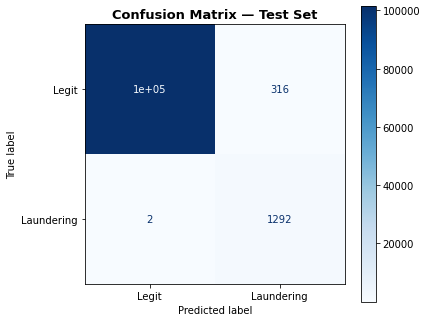

In [ ]:
from model.gagnn import GAGNN
from utils import Evaluator
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GAGNN.load_saved("saved_models/gagnn_best.pt").to(device)

Evaluator.evaluation_report(model, test_loader, criterion, device)


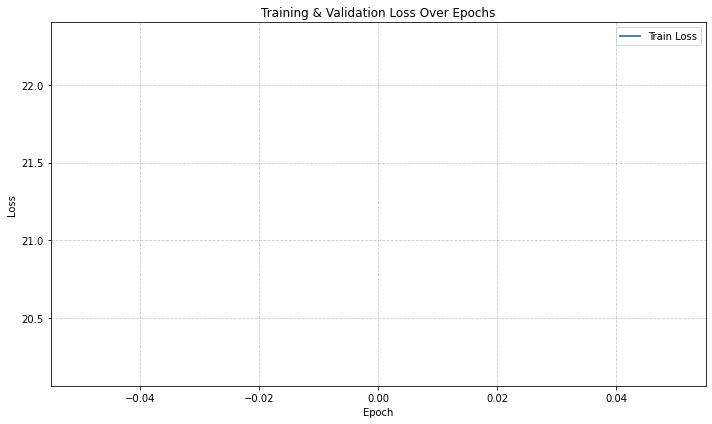

In [ ]:
model.plot_training_history()
